In [1]:
import sys
from pathlib import Path
HERE = Path.cwd().resolve()
up1_path = str((HERE / ".." ).resolve())
up2_path = str((HERE / ".." / ".." ).resolve())
data1_prefix = str((HERE / ".." / "e-region-convergence").resolve())
for pathstr in [up1_path, up2_path]:
  if pathstr not in sys.path:
      sys.path.insert(0, pathstr)

from helpers import *
import numpy as np
from prediction_evaluators import *
import copy

In [7]:
def m0h_model():
  def model(vars, a1, a2, a3, a4):
    m0h = vars[0]
    alpha = a1 * np.log(m0h + a2) + a3
    beta = a4
    return alpha, beta
  variables_used = ["m0h"]
  guess = (1, 1, 1, 2)
  return model, variables_used, guess

In [3]:
file1 = data1_prefix + "/data/predetermined-2.pkl"
f1_data = open_pkl_file(file1)
for pset in f1_data:
  generate_convergence_data(pset, [0.01])
  generate_log_data(pset)
f1_data = [filter_converged(pset) for pset in f1_data]

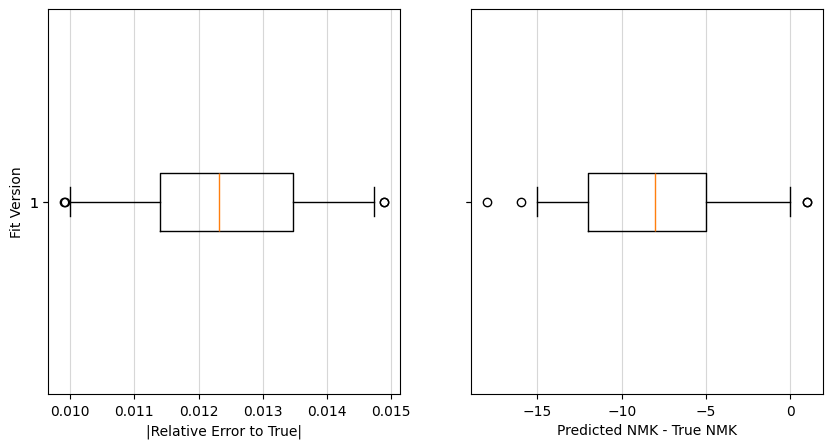

Sample size: 33
Average Errors: 0.0124
STDEV Errors: 0.00142
Average NMK off: -8.39
STDEV NMK off: 4.81


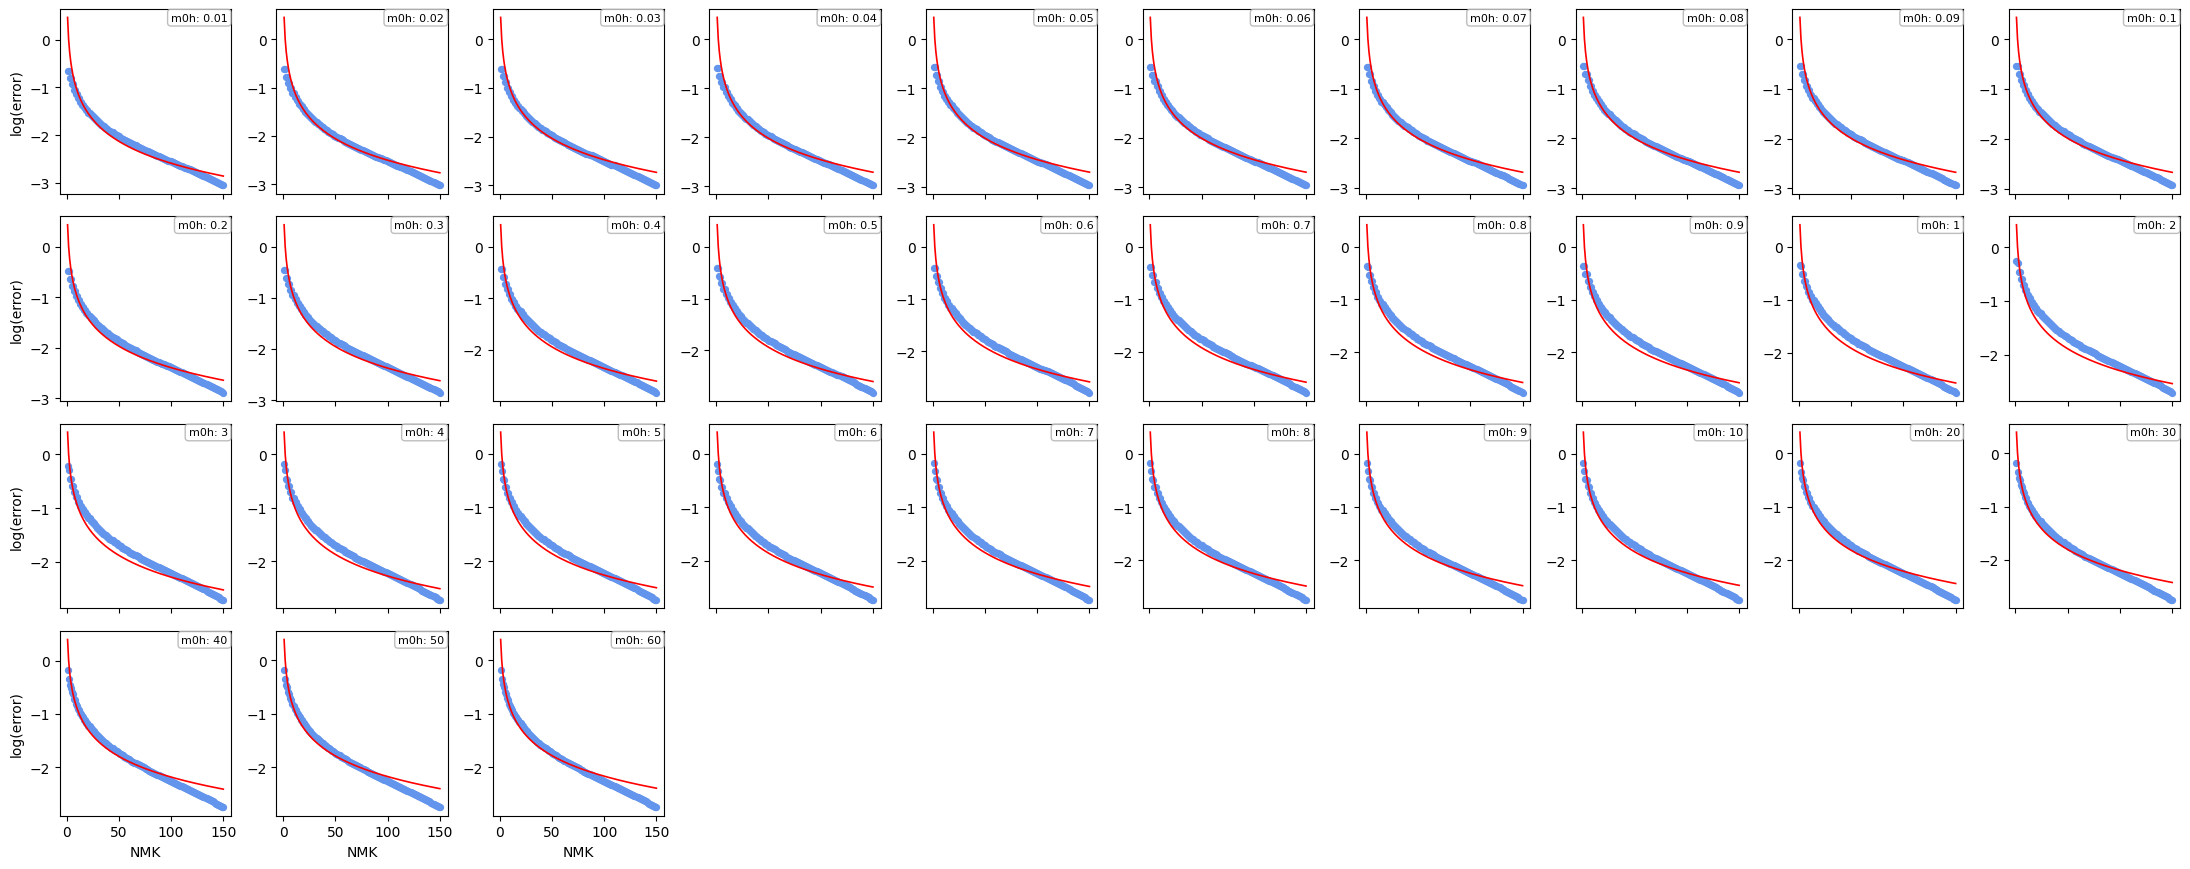

In [13]:
variables_used, guess, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = variables_guess_variants(m0h_model, region = 3)
cfs, hydro = f1_data[1], "am"
params_dict= {}
params, res = fit_exterior_model_weighted(cfs, hydro, fit_model, guess, variables_used, underweight = 1)
key = str(1)
params_dict[key] = (twenty_minimum(nmk_from_err_model), params)
statpacks = compare_abs_nmk_rel_err(f1_data[1], hydro, params_dict, 0.01, nmk_big = 200)
print_err_nmk_abs_from_statpacks(statpacks)
summary_fs = {"m0h" : lambda cf : cf["h"]*cf["m0s"][0]}
err_from_nmk_full = lambda nmk : np.log10(err_from_nmk_model(nmk, params_dict["1"][1]))
sub_data = f1_data[1]
compare_model_curves(sub_data, extractf_am, model_wrapper(lambda cf, m0 : cf_params_to_alpha_beta(cf, m0, *params_dict["1"][1])), summary_fs)